**🔹 Step 1: Mount Drive**

In [11]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


**🔹 Step 2: Paths**

In [12]:
BASE_PATH = "/content/drive/MyDrive/ResearchModels/Paper1"
MODEL_PATH = f"{BASE_PATH}/models/distilbert_sst2"

**🔹 Step 3: Imports**

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast


**🔹 Step 4: Load model WITH attentions enabled**

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_PATH,
    output_attentions=True,
    use_safetensors=True
).to(device)

model.eval()

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_PATH)

print("✅ Model loaded with attentions enabled")


✅ Model loaded with attentions enabled


**🔹 Step 5: Input sentence (same style as IG)**

In [15]:
text = "The movie was absolutely wonderful and engaging."

encoded = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    max_length=128
)

input_ids = encoded["input_ids"].to(device)
attention_mask = encoded["attention_mask"].to(device)


**🔹 Step 6: Forward pass to get attentions**

In [16]:
with torch.no_grad():
    outputs = model(input_ids=input_ids, attention_mask=attention_mask)

attentions = outputs.attentions


👉 attentions is a tuple:

length = number of layers

shape per layer = (batch, heads, tokens, tokens)

**🔹 Step 7: ATTENTION ROLLOUT computation**

In [17]:
# Stack attentions: (layers, heads, tokens, tokens)
attentions = torch.stack(attentions).squeeze(1)

# Average across heads
attentions_mean = attentions.mean(dim=1)

# Add identity matrix (residual connection)
num_tokens = attentions_mean.size(-1)
identity = torch.eye(num_tokens).to(device)

augmented_attentions = attentions_mean + identity
augmented_attentions = augmented_attentions / augmented_attentions.sum(dim=-1, keepdim=True)

# Rollout
rollout = augmented_attentions[0]
for i in range(1, augmented_attentions.size(0)):
    rollout = torch.matmul(augmented_attentions[i], rollout)

# CLS token attention
cls_attention = rollout[0]


**🔹 Step 8: Map attention to tokens**

In [18]:
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
cls_attention = cls_attention.detach().cpu().numpy()

for token, score in zip(tokens, cls_attention):
    print(f"{token}: {score:.4f}")


[CLS]: 0.3544
the: 0.0488
movie: 0.0263
was: 0.0320
absolutely: 0.0296
wonderful: 0.0406
and: 0.0435
engaging: 0.0343
.: 0.0919
[SEP]: 0.2985


**🔹 Step 9: Visualization**

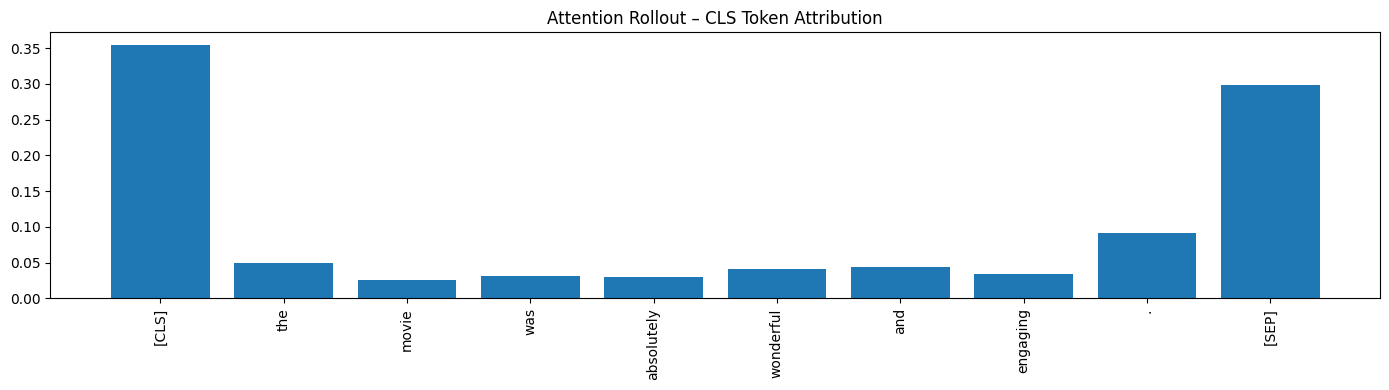

Plot saved at: /content/drive/MyDrive/ResearchModels/Paper1/plots/attention_plots/attention_rollout.png


In [19]:
plt.figure(figsize=(14,4))
plt.bar(tokens, cls_attention)
plt.xticks(rotation=90)
plt.title("Attention Rollout – CLS Token Attribution")
plt.tight_layout()

save_path = "/content/drive/MyDrive/ResearchModels/Paper1/plots/attention_plots/attention_rollout.png"
!mkdir -p /content/drive/MyDrive/ResearchModels/Paper1/plots/attention_plots
plt.savefig(save_path)
plt.show()

print("Plot saved at:", save_path)
